In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# EDA

In [4]:
df = pd.read_csv("diamonds.csv")

In [5]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [7]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [8]:
df.shape

(53940, 10)

In [9]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

In [10]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


## Problem Statement
The objective of this project is to analyze the diamond dataset and build a machine learning model to predict the price of diamonds based on their physical and quality-related attributes such as carat, cut, color, clarity, depth, and dimensions.

In [11]:
df.duplicated().sum()

np.int64(146)

In [12]:
# removing the duplicates
df = df.drop_duplicates()

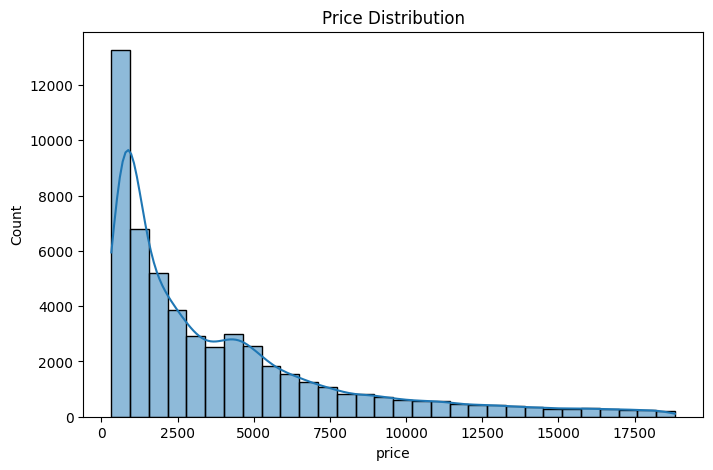

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Price Distribution")
plt.show()

The price distribution is positively skewed, indicating that most diamonds are available at lower prices while only a few diamonds are extremely expensive.

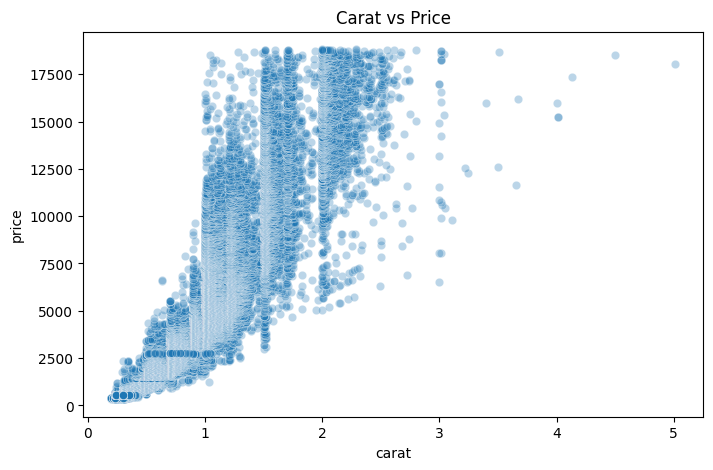

In [14]:
#plt.figure(figsize=(8,5))
#sns.scatterplot(x='carat', y='price', data=df)
#plt.title("Carat vs Price")
#plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='carat',
    y='price',
    data=df,
    alpha=0.3
)
plt.title("Carat vs Price")
plt.show()

There is a strong positive correlation between carat and price. Diamonds with higher carat values generally have higher prices.

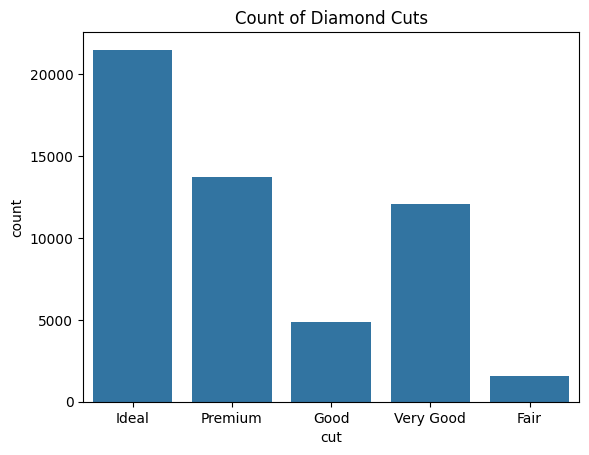

In [15]:
sns.countplot(x='cut', data=df)
plt.title("Count of Diamond Cuts")
plt.show()

Ideal cut diamonds appear most frequently in the dataset, while Fair cut diamonds are comparatively rare.

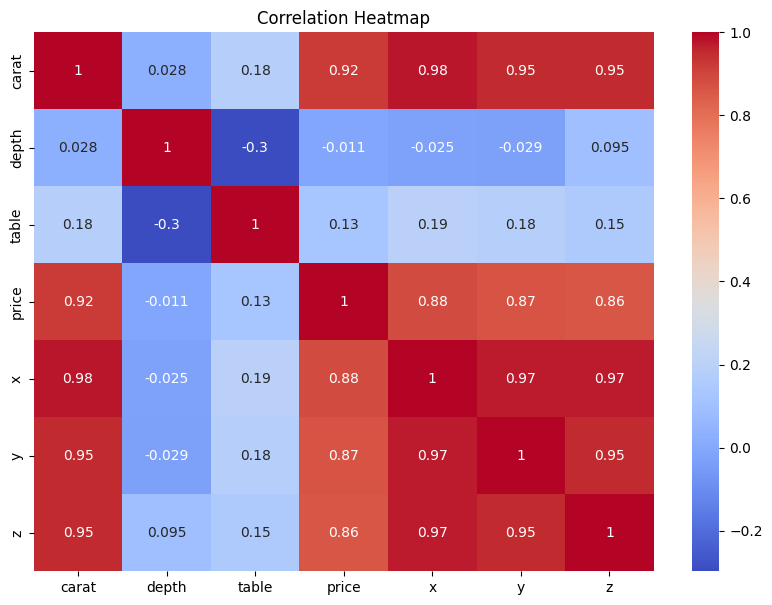

In [16]:
plt.figure(figsize=(10,7))
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

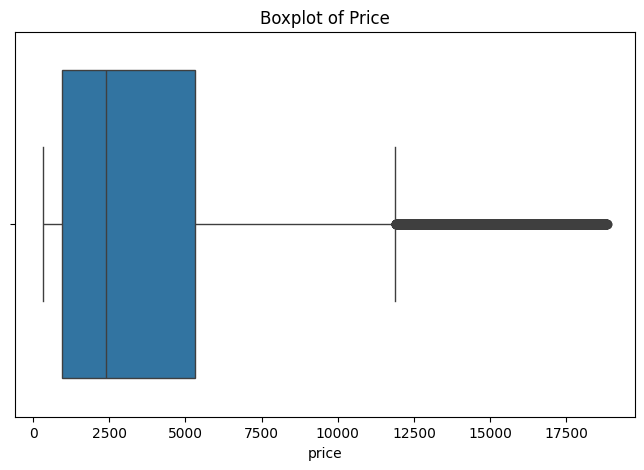

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['price'])

plt.title("Boxplot of Price")
plt.show()

The price column contains many outliers, indicating the presence of highly expensive diamonds compared to the majority of the dataset.

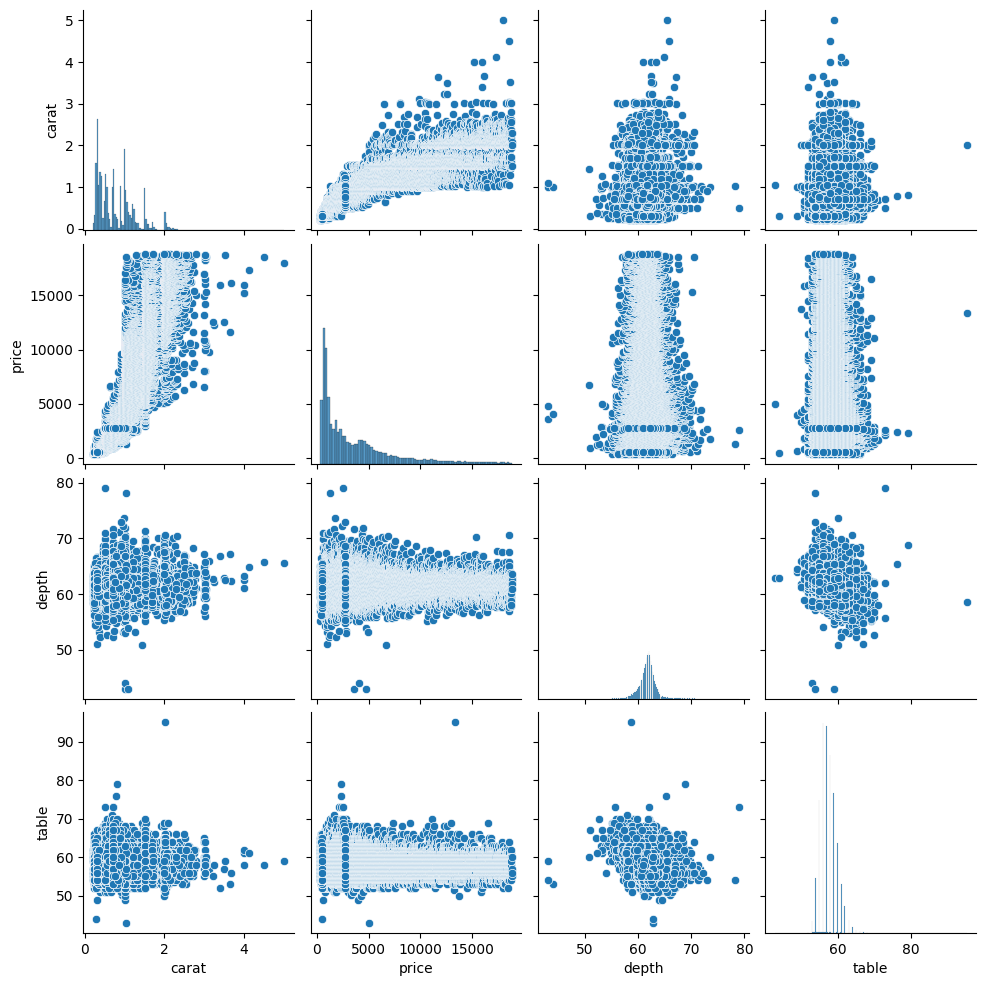

In [18]:
sns.pairplot(
    df[['carat', 'price', 'depth', 'table']]
)

plt.show()

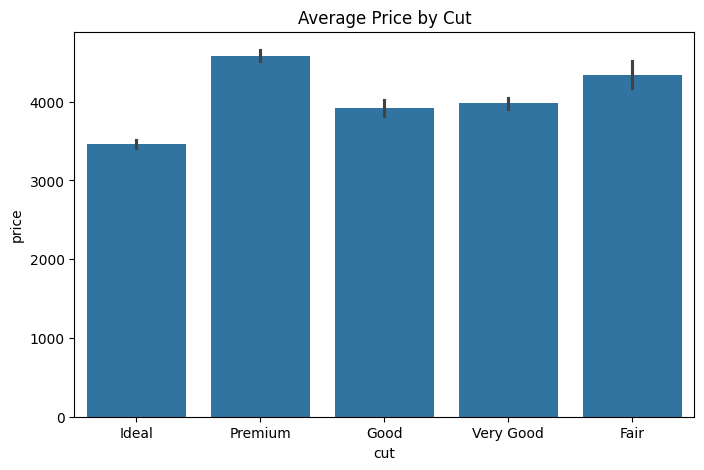

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='cut',
    y='price',
    data=df
)

plt.title("Average Price by Cut")
plt.show()

Premium cut diamonds have the highest average price, while Ideal cut diamonds have comparatively lower average prices. This indicates that factors like carat may influence price more strongly than cut quality alone.

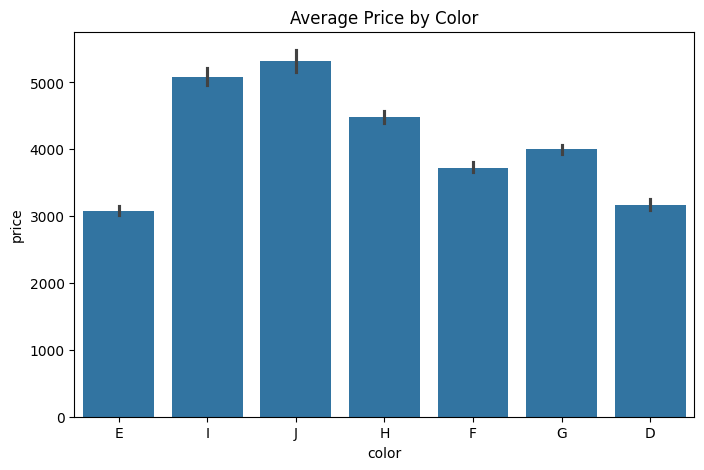

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='color',
    y='price',
    data=df
)

plt.title("Average Price by Color")
plt.show()

Some lower color grades show higher average prices, suggesting that diamond price is influenced by multiple factors such as carat and dimensions, not only color quality.

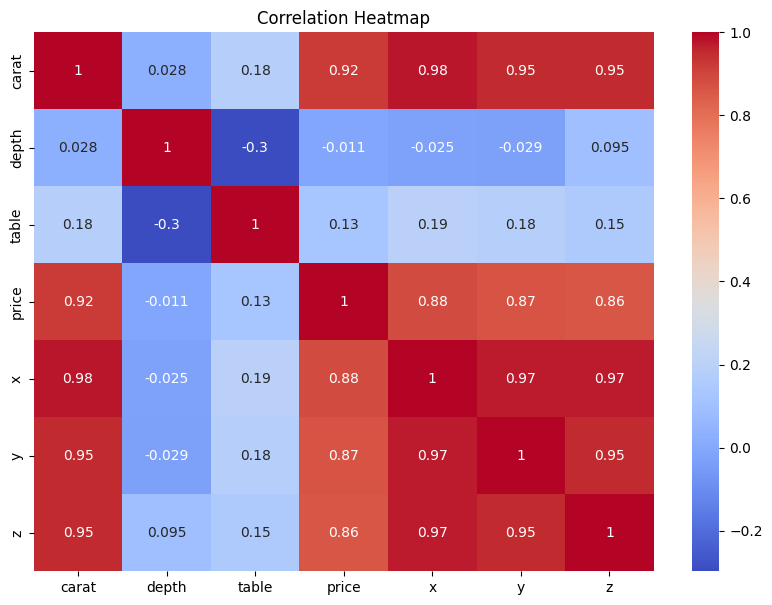

In [22]:
plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

Carat has a very strong positive correlation with price, making it one of the most important predictors for diamond price estimation.


### Summary :
The dataset contains both numerical and categorical features related to diamond characteristics.
The price distribution is positively skewed, indicating that most diamonds are lower priced while only a few are very expensive.
Carat shows a strong positive correlation with price, making it one of the most influential features.
The dimensions x, y, and z also show strong positive correlations with price.
Depth and table show weak relationships with price.
Several numerical features such as x, y, and z are highly correlated with each other, indicating multicollinearity.
The dataset contains outliers in the price column, representing highly expensive diamonds.


# Preprocessing

In [23]:
X = df.drop('price',axis = 1)
y = df["price"]

In [24]:
X.select_dtypes(include='object').columns

Index(['cut', 'color', 'clarity'], dtype='object')

In [26]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [27]:
for col in ['cut', 'color', 'clarity']:
    X[col] = le.fit_transform(X[col])

In [28]:
X.head()

,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,2,1,3,61.5,55.0,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,4.34,4.35,2.75


In [29]:
# Train-Test-Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
print(X_train.shape)
print(X_test.shape)

(43035, 9)
(10759, 9)


# Feature Scaling

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()

In [34]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Algorithm

#### LINEAR REGRESSION

In [36]:
from sklearn.linear_model import LinearRegression

In [39]:
lr = LinearRegression()

In [40]:
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [41]:
y_pred = lr.predict(X_test_scaled)

In [42]:
# Evaluation metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [49]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)
# average prediction error : lower is better

MAE: 840.744751623145


In [45]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 1722518.018368221


In [51]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)
# almost equal to 1 means better model

R2 Score: 0.8869892348179879


In [50]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)
#Punishes larger errors more strongly : Lower is better

RMSE: 1312.4473392743118


In [52]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
results.head()

,Actual,Predicted
43657,1435,2151.157695
4274,3584,4856.204930
47412,1851,1905.023426
44437,1590,1954.033589
13975,5690,5960.781051


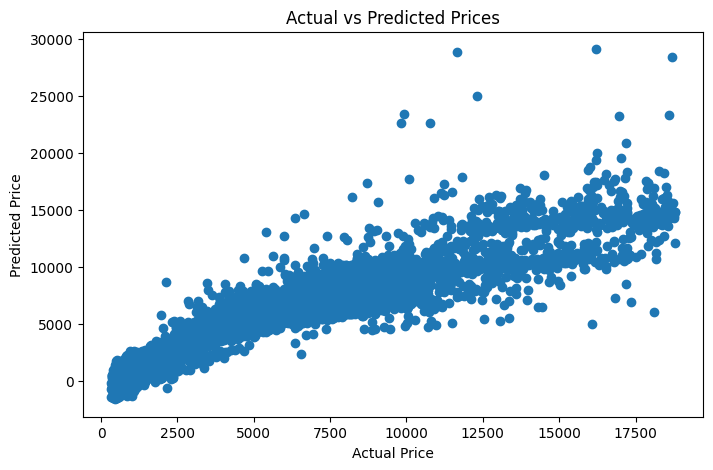

In [53]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

The Linear Regression model captures the general trend between actual and predicted prices. However, prediction errors increase for higher-priced diamonds, indicating that the relationship between features and price is not perfectly linear.
The Linear Regression model achieved an R² score of 0.887, indicating strong predictive performance. The model successfully captured the relationship between diamond attributes and price, although prediction errors increased for higher-priced diamonds.

#### Decision Tree Regressor

In [56]:
from sklearn.tree import DecisionTreeRegressor

In [58]:
dt = DecisionTreeRegressor( random_state=42)

In [60]:
dt.fit(X_train,y_train)

DecisionTreeRegressor(random_state=42)

In [61]:
y_pred_dt = dt.predict(X_test)

In [62]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

r2_dt = r2_score(y_test, y_pred_dt)

print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

MAE: 351.8422715865787
RMSE: 711.8968161323711
R2 Score: 0.966750115335441


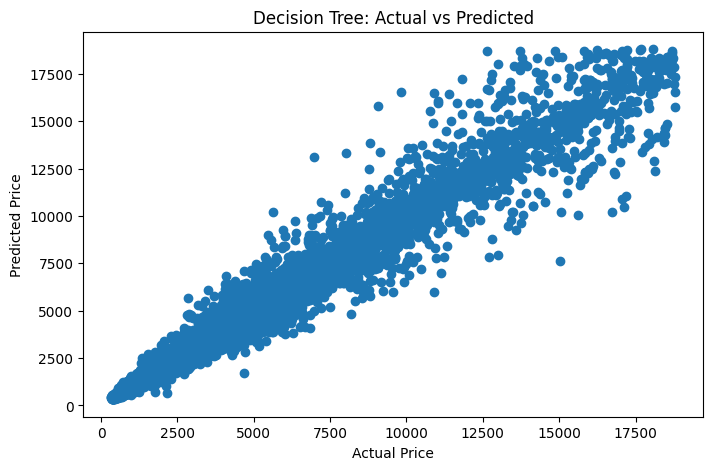

In [63]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree: Actual vs Predicted")

plt.show()

#### Random Forest

In [64]:
from sklearn.ensemble import RandomForestRegressor

In [65]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [66]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [67]:
y_pred_rf = rf.predict(X_test)

In [68]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 262.82740140627925
MSE: 269758.377978096
RMSE: 519.3826893323419
R2 Score: 0.982301723184038


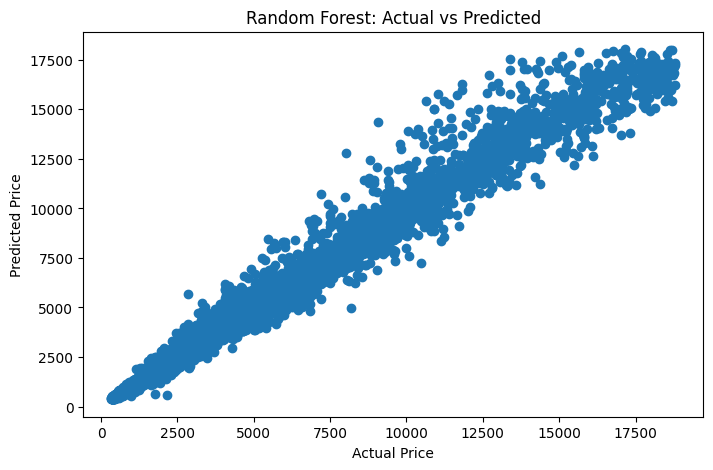

In [69]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

# ALL Models Comparision

In [70]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'R2 Score': [
        r2,
        r2_dt,
        r2_rf
    ],

    'MAE': [
        mae,
        mae_dt,
        mae_rf
    ],

    'RMSE': [
        rmse,
        rmse_dt,
        rmse_rf
    ]
})

comparison

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.886989,840.744752,1312.447339
1,Decision Tree,0.966750,351.842272,711.896816
2,Random Forest,0.982302,262.827401,519.382689


In [73]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance',ascending=False)

importance
# This is best thing in random forest which tells about the important features


,Feature,Importance
0,carat,0.489559
7,y,0.398668
3,clarity,0.064351
2,color,0.029380
8,z,0.005893
6,x,0.004906
4,depth,0.003363
5,table,0.002483
1,cut,0.001397


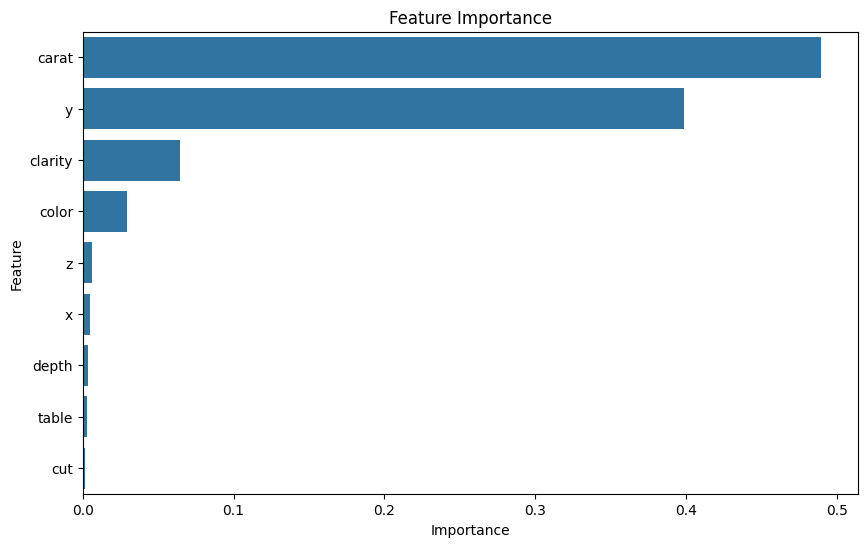

In [74]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title("Feature Importance")

plt.show()

# Model saving

In [75]:
import pickle

In [77]:
pickle.dump(rf,open('diamond_price_model.pkl', 'wb'))
# Saves model which is trained

In [78]:
loaded_model = pickle.load(open('diamond_price_model.pkl', 'rb'))

# Testing the model

In [79]:
sample = [[
    1.0,   # carat
    2,     # cut
    3,     # color
    4,     # clarity
    61.5,  # depth
    55,    # table
    6.4,   # x
    6.3,   # y
    3.9    # z
]]

In [80]:
prediction = loaded_model.predict(sample)
print(prediction)

[6343.36]


# Conclusion
This project analyzed the diamond dataset and developed multiple machine learning regression models to predict diamond prices.

Exploratory Data Analysis revealed that carat, x, y, and z dimensions strongly influence price, while depth and table have weaker relationships.

Three regression models were trained and evaluated:

Linear Regression,
Decision Tree Regressor,
Random Forest Regressor

Among all models, the Random Forest Regressor achieved the best performance with the highest R² score and lowest prediction errors.

The final model successfully predicts diamond prices with high accuracy and can be deployed for real-world applications.

In [81]:
for col in ['cut', 'color', 'clarity']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

    print(col)
    print(le.classes_)

cut
['Fair' 'Good' 'Ideal' 'Premium' 'Very Good']
color
['D' 'E' 'F' 'G' 'H' 'I' 'J']
clarity
['I1' 'IF' 'SI1' 'SI2' 'VS1' 'VS2' 'VVS1' 'VVS2']
